# Deep Agents - Quickstart


## 1. Deep Agents란?

`Deep Agents`는 `LangGraph` 기반으로 구축된 고급 AI 에이전트 프레임워크입니다.

### 핵심 기능
1. **복잡한 작업 처리**: 다단계 작업을 계획하고 분해할 수 있습니다
2. **파일 시스템 도구**: 대량의 컨텍스트를 파일로 관리합니다
3. **Subagent 위임**: 특수화된 하위 에이전트에게 작업을 위임하여 컨텍스트를 격리합니다
4. **영구 메모리**: 대화 및 스레드 간 메모리를 유지합니다

### DeepAgents vs LangGraph

`DeepAgents`는 `LangGraph`보다 더 자동화된 에이전트 프레임워크이고, `LangGraph`는 `workflow 설계` 중심 에이전트 프레임워크입니다.

DeepAgents는 
> "내가 알아서 파일 저장도 하고, 계획도 세우고, sub-agent도 만들고,     
> 컨텍스트 정리도 하고, 작업을 쪼개서 처리할게.     
> LangGraph처럼 사람이 DAG 설계하지 않아도 돼."     

반대로 LangGraph는:
> "네가 설계해라.    
> 노드/엣지/상태 흐름을 네가 제어해라.    
> 난 framework일 뿐이야."    

| 기능           | DeepAgents (내장)                  | LangGraph            |
| ------------ | -------------------------------- | -------------------- |
| 상태 관리(State) | 자체 backend / store 지원            | DAG 기반 state machine |
| 멀티스텝 작업      | Todo + subagent + 계획 기능 내장       | DAG 노드간 메세지 전달       |
| 컨텍스트 관리      | 자동 요약 / 파일 저장 / context eviction | 그래프 노드의 state 유지     |
| Worker 분리    | subagents                        | 여러 agent 노드 구성       |
| 롱런 작업 관리     | harness가 자동 처리                   | 그래프체크포인트로 안정적 운영     |


### DeepAgents vs Swarm vs LangGraph


| 항목            | Swarm             | DeepAgents               | LangGraph           |
| ------------- | ----------------- | ------------------------ | ------------------- |
| 철학            | 단순 agent routing  | 자동화된 오토에이전트              | DAG 기반 workflow     |
| 상태 관리         | 거의 없음             | strong (harness)         | 매우 strong           |
| 복잡도           | 매우 낮음             | 중간                       | 높음                  |
| 확장성           | 낮음                | 중간~높음                    | 매우 높음               |
| 용도            | Agent2Agent 프로토타입 | 파일/메모리/하위작업 포함 자동 AI 작업기 | 엔터프라이즈급 멀티 에이전트 시스템 |


## 2. 환경 변수 설정 
- [OpenAI API Key](https://platform.openai.com/api-keys)
- [LangSmith API Key](https://smith.langchain.com/)

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

## 3. 첫 번째 Deep Agent 만들기


### Chat LLM 생성

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)

### MemorySaver 생성 

In [3]:
# Checkpointer 임포트 및 생성
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
print("Checkpointer가 생성되었습니다!")

Checkpointer가 생성되었습니다!


### 기본 Agent 생성

`create_deep_agent()` 함수를 사용하면 간단하게 Deep Agent를 생성할 수 있습니다.

In [4]:
from deepagents import create_deep_agent

# 기본 설정으로 Agent 생성
agent = create_deep_agent(
    model=llm,
    checkpointer=checkpointer,
    system_prompt="""
    당신은 도움이 되는 연구 어시스턴트입니다. 사용자의 질문에 답하기 위해 조사하고 보고서를 작성합니다."""
) 

print("Deep Agent가 성공적으로 생성되었습니다!")


Deep Agent가 성공적으로 생성되었습니다!


## 4. Agent 실행하기

### 간단한 질문으로 테스트


In [5]:
import uuid

thread_id = str(uuid.uuid4())
print(f"thred_id: {thread_id}")

thred_id: 27f31a59-3959-4b27-906c-e021f079c584


In [6]:
from langchain.messages import HumanMessage

# Agent에게 간단한 작업 요청
response = agent.invoke(
    {"messages": [HumanMessage(content="안녕하세요! Deep Agents에 대해 간단히 설명해주세요.")]},
    config={"configurable": {"thread_id": thread_id}}
)


In [7]:
# 응답 출력
print("Agent 응답:")
print(response["messages"][-1].content)

Agent 응답:
간단히 말하면, 딥 에이전트(Deep Agent)는 환경과 상호작용하면서 보상을 최대화하도록 행동을 학습하는 자율 시스템입니다. 여기서 “딥”은 심층 신경망을 사용해 입력을 이해하고 적절한 정책이나 가치 함수를 근사한다는 뜻입니다.

주요 포인트
- 무엇을 하는가: 관찰한 상태에서 어떤 행동을 할지 결정하고, 그 결과로 얻은 보상을 통해 성능을 점진적으로 향상시킵니다.
- 딥러닝의 역할: 이미지 같은 고차원 입력을 처리하고, 정책(무엇을 할지)이나 가치(그 상태에서 어떤 행동이 좋은지)를 예측하는 네트워크를 학습합니다.
- 학습 방식: 주로 강화학습으로 에피소드를 통해 데이터를 모으고, 이 데이터를 이용해 네트워크의 파라미터를 업데이트합니다. 온-폴리시(예: PPO)나 오프-폴리시(예: DQN) 방식이 있습니다.
- 일반적인 구성: 입력(상태) → 신경망(정책/가치 예측) → 액션 선택 → 환경으로부터 보상과 새 상태 수집.
- 대표 알고리즘 예시: DQN, PPO, SAC, TD3, A3C 등.
- 장점과 도전과제:
  - 장점: 원시 입력(픽셀 이미지 등)에서 직접 학습 가능, 복잡한 과제에 확장 가능.
  - 도전과제: 데이터(샘플) 소모가 많고, 학습 안정성·하이퍼파라미터 감도, 계산 자원이 많이 필요합니다.
- 실생활 응용 예: 비디오 게임 플레이, 로봇 팔 제어, 시뮬레이션 기반 자율주행, 추천 시스템의 의사결정 등.

간단한 예시
- 비디오게임에서 화면의 픽셀을 입력으로 받아 점수를 최대화하도록 학습하는 에이전트가 한 예입니다. 에이전트는 게임을 플레이하며 얻은 보상을 바탕으로 더 나은 움직임을 배우죠.

필요하시면 특정 프레임워크나 예제(예: OpenAI Gym에서의 간단한 DQN 구현)로 더 자세히 설명해 드리겠습니다. 어떤 부분이 더 궁금하신가요?


### 복잡한 연구 작업 수행하기

Deep Agent는 복잡한 다단계 작업을 수행할 수 있습니다.


In [8]:
# 연구 작업 요청
research_task = """
AI 에이전트의 최신 트렌드에 대해 조사하고, 
다음 내용을 포함한 간단한 보고서를 작성해주세요:
1. 주요 트렌드 3가지
2. 각 트렌드의 핵심 특징
3. 향후 전망
"""

response = agent.invoke(
    {"messages": [HumanMessage(content=research_task)]},
    config={"configurable": {"thread_id": "demo-research"}}
)


In [9]:
print("연구 결과:")
print(response["messages"][-1].content)


연구 결과:
다음은 AI 에이전트의 최신 트렌드에 대한 간단한 보고서입니다.

1) 주요 트렌드 3가지
- 트렌드 1: 자율성 강화 및 장기 계획 기반 에이전트의 확산
- 트렌드 2: 도구 활용 및 실시간 데이터 접근, 멀티모달 입력/출력 능력의 확장
- 트렌드 3: 안전성·거버넌스·신뢰성 강화 및 규제 대응

2) 각 트렌드의 핵심 특징
- 트렌드 1: 자율성 강화 및 장기 계획 기반 에이전트
  - 특징
    - 목표 지향적 의사결정 및 계획-실행 루프를 통해 사람의 개입을 최소화하는 자동화 추구
    - 긴 맥락 기억(memories/장기 메모리)으로 과거 맥락을 활용한 의사결정 가능
    - 피드백 루프를 통한 지속적 개선과 자동 미세조정 가능
    - 실제 적용 예시: 고객지원 자동화, IT 운영 자동화, 연구·분석 보조 등
    - 리스크/도전: 예측 불가한 행동, 안전성 문제, 제어의 복잡성 증가
- 트렌드 2: 도구 활용 및 실시간 데이터 접근, 멀티모달 에이전트의 확장
  - 특징
    - 외부 도구·API 연결(플러그인 아키텍처)로 기능 범위 확장
    - 웹 검색 및 실시간 데이터 접근으로 최신 정보 반영 가능
    - 텍스트/이미지/음성 등 멀티모달 입력·출력 및 코드 실행 등 다양한 형태의 인터랙션 지원
    - 다중 에이전트의 협력・파이프라인 구성으로 복합 작업 처리 강화
    - 보안·개인정보 관리의 중요성 증가
- 트렌드 3: 안전성·거버넌스·신뢰성 강화 및 규제 대응
  - 특징
    - 정책 기반 제어, 로그/추적 가능성 확보로 투명성 강화
    - 인간 감독(Human-in-the-Loop) 및 승인 절차를 통한 안전성 보장
    - 위험 관리, 윤리 가이드라인 준수, 데이터 프라이버시 보호 강화
    - 규제 대응 준비 및 감사 가능성 확보를 위한 프레임워크 필요
    - 운영 비용과 거버넌스 오버헤드 관리의 필요성 증가

3) 향후 전망
- 단기(1-2년)
  - 기업용 에이전트 플랫폼의 보급 가

## 5. Agent 상태 확인하기

Agent의 현재 상태를 확인할 수 있습니다.

In [19]:
print(f"간단한 질문으로 테스트에서 사용한 thread_id: {thread_id}")

간단한 질문으로 테스트에서 사용한 thread_id: 27f31a59-3959-4b27-906c-e021f079c584


In [20]:
# Agent 상태 가져오기
state = agent.get_state(config={"configurable": {"thread_id": thread_id}})

print("Agent 상태 정보:")
print(f"메시지 수: {len(state.values.get('messages', []))}")
print(f"다음 노드: {state.next}")
print(f"작업 완료: {len(state.next) == 0}")
print("="*50)
print(f"마지막 메시지:\n{state.values['messages'][-1].content}")


Agent 상태 정보:
메시지 수: 2
다음 노드: ()
작업 완료: True
마지막 메시지:
간단히 말하면, 딥 에이전트(Deep Agent)는 환경과 상호작용하면서 보상을 최대화하도록 행동을 학습하는 자율 시스템입니다. 여기서 “딥”은 심층 신경망을 사용해 입력을 이해하고 적절한 정책이나 가치 함수를 근사한다는 뜻입니다.

주요 포인트
- 무엇을 하는가: 관찰한 상태에서 어떤 행동을 할지 결정하고, 그 결과로 얻은 보상을 통해 성능을 점진적으로 향상시킵니다.
- 딥러닝의 역할: 이미지 같은 고차원 입력을 처리하고, 정책(무엇을 할지)이나 가치(그 상태에서 어떤 행동이 좋은지)를 예측하는 네트워크를 학습합니다.
- 학습 방식: 주로 강화학습으로 에피소드를 통해 데이터를 모으고, 이 데이터를 이용해 네트워크의 파라미터를 업데이트합니다. 온-폴리시(예: PPO)나 오프-폴리시(예: DQN) 방식이 있습니다.
- 일반적인 구성: 입력(상태) → 신경망(정책/가치 예측) → 액션 선택 → 환경으로부터 보상과 새 상태 수집.
- 대표 알고리즘 예시: DQN, PPO, SAC, TD3, A3C 등.
- 장점과 도전과제:
  - 장점: 원시 입력(픽셀 이미지 등)에서 직접 학습 가능, 복잡한 과제에 확장 가능.
  - 도전과제: 데이터(샘플) 소모가 많고, 학습 안정성·하이퍼파라미터 감도, 계산 자원이 많이 필요합니다.
- 실생활 응용 예: 비디오 게임 플레이, 로봇 팔 제어, 시뮬레이션 기반 자율주행, 추천 시스템의 의사결정 등.

간단한 예시
- 비디오게임에서 화면의 픽셀을 입력으로 받아 점수를 최대화하도록 학습하는 에이전트가 한 예입니다. 에이전트는 게임을 플레이하며 얻은 보상을 바탕으로 더 나은 움직임을 배우죠.

필요하시면 특정 프레임워크나 예제(예: OpenAI Gym에서의 간단한 DQN 구현)로 더 자세히 설명해 드리겠습니다. 어떤 부분이 더 궁금하신가요?


## 6. Agent의 실행 과정 살펴보기

Deep Agent가 작업을 어떻게 수행하는지 단계별로 확인할 수 있습니다.


In [10]:
# 스트리밍 모드로 실행 과정 확인
task = "Python으로 간단한 계산기 프로그램을 만드는 방법을 설명해주세요."

print("Agent 실행 과정:\n")

for chunk in agent.stream(
    {"messages": [HumanMessage(content=task)]},
    config={"configurable": {"thread_id": "demo-stream"}},
    stream_mode="updates"
):
    # 각 단계의 출력 표시
    for node_name, node_output in chunk.items():
        print(f"노드: {node_name}")
        if isinstance(node_output, dict) and "messages" in node_output:
            _messages = []
            if isinstance(node_output["messages"], list):
                _messages = node_output["messages"]
            elif hasattr(node_output["messages"], 'value'):
                _messages = node_output["messages"].value

            for msg in _messages:
                if hasattr(msg, 'content') and msg.content:
                    print(f"{msg.content}")


Agent 실행 과정:

노드: PatchToolCallsMiddleware.before_agent
Python으로 간단한 계산기 프로그램을 만드는 방법을 설명해주세요.
노드: SummarizationMiddleware.before_model
노드: model
다음은 Python으로 간단한 콘솔 기반 계산기를 만드는 두 가지 방법과 예제 코드입니다. 기본적으로 네 가지 연산자(+ - * /)를 지원하는 버전이므로 시작하기 쉽습니다.

1) 방법 A: 사용자가 두 숫자와 연산자를 순서대로 입력하는 3단계 방식
- 흐름: 첫 숫자 입력 → 연산자 입력 → 두 번째 숫자 입력 → 결과 출력
- 장점: 입력 형식이 직관적이고 예외 처리도 비교적 단순합니다.

예제 코드 (3단계 입력 버전)
def main():
    print("간단한 계산기 - 두 숫자와 연산자를 입력해 결과를 출력합니다.")
    print("종료하려면 q를 입력하세요.")
    while True:
        a_str = input("첫 번째 숫자: ").strip()
        if a_str.lower() in ('q','quit','exit'):
            break
        try:
            a = float(a_str)
        except ValueError:
            print("유효한 숫자가 아닙니다.")
            continue

        op = input("연산자(+,-,*,/): ").strip()
        if op.lower() in ('q','quit','exit'):
            break
        if op not in '+-*/':
            print("지원되지 않는 연산자입니다.")
            continue

        b_str = input("두 번째 숫자: ").strip()
        if b_str.lower() in ('q

## 7. 기본 파일 시스템 활용

Deep Agent는 내장된 파일 시스템을 사용하여 정보를 저장하고 관리할 수 있습니다.

### 파일 시스템 작업 요약

Deep Agent의 파일 시스템은 다음과 같은 특징이 있습니다:

1. **자연어 인터페이스**: Agent에게 자연어로 파일 작업을 요청할 수 있습니다
2. **가상 파일 시스템**: Deep Agent가 관리하는 내부 저장소를 사용합니다
3. **Thread 격리**: 각 thread_id는 독립적인 파일 시스템 공간을 가집니다
4. **주요 작업**:
   - 파일 생성 및 쓰기
   - 파일 읽기
   - 파일 목록 조회
   - 파일 수정 및 삭제
   - 디렉토리 생성 및 관리

**참고**: 같은 `thread_id`를 사용하면 이전에 생성한 파일에 접근할 수 있습니다.

### 파일 생성 및 관리 작업

In [11]:
# 파일 생성 및 관리 작업
file_task = """
다음 작업을 수행해주세요:
1. 'notes.txt'라는 파일을 만들고 "Deep Agents 학습 시작"이라고 작성
2. 파일 내용을 읽어서 확인
3. 파일 목록을 보여주세요
"""

response = agent.invoke(
    {"messages": [HumanMessage(content=file_task)]},
    config={"configurable": {"thread_id": "demo-files"}}
)


Deep Agent 내장 파일 시스템 특징 
1. `내부 저장소`: Deep Agents가 관리하는 메모리 기반 또는 backend 저장소에 저장됩니다
2. `경로`: /notes.txt (가상 파일 시스템의 루트)
3. `접근 방법`: Agent의 파일 도구를 통해서만 접근 가능합니다
4. `물리적 위치`: Windows 파일 시스템에는 실제로 생성되지 않습니다

In [12]:
print("파일 시스템 작업 결과:")
print(response["messages"][-1].content)


파일 시스템 작업 결과:
다음 작업을 완료했습니다.

1) /notes.txt 파일 생성 및 내용 작성
- 내용: Deep Agents 학습 시작

2) 파일 내용 읽어 확인
- /notes.txt 내용 확인: "Deep Agents 학습 시작"

3) 파일 목록 표시
- 루트(/) 디렉터리의 파일 목록: /notes.txt

다른 파일이 필요한 경우 말씀해 주세요.


#### [Langsmith](https://smith.langchain.com/)

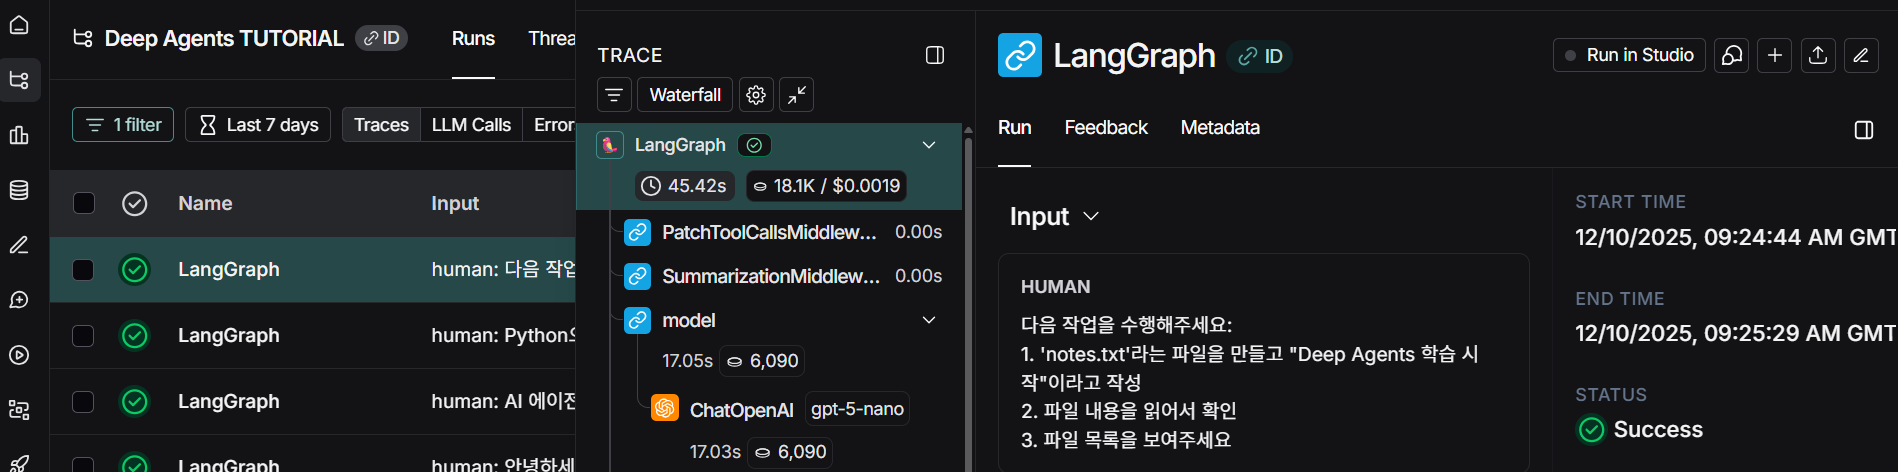

### 저장된 파일 리스트 조회하기

Deep Agent에게 자연어로 파일 목록을 조회하도록 요청할 수 있습니다.

In [13]:
from langchain.messages import HumanMessage

# 파일 리스트 조회 요청
list_files_request = """
현재 파일 시스템에 저장된 모든 파일의 목록을 보여주세요.
루트 디렉토리(/)의 파일 목록을 나열해주세요.
"""

# Agent에게 파일 목록 조회 요청
response = agent.invoke(
    {"messages": [HumanMessage(content=list_files_request)]},
    config={"configurable": {"thread_id": "demo-files"}}
)


In [14]:
# 결과 출력
print("저장된 파일 목록:")
print(response["messages"][-1].content)

저장된 파일 목록:
다음과 같이 확인했습니다.

- 현재 파일 시스템에 저장된 모든 파일 목록
  - /notes.txt

- 루트 디렉토리 (/)의 파일 목록
  - /notes.txt

- 비공개(dot) 파일 여부
  - 발견되지 않음 (숨김 파일은 없음)

다른 파일이나 디렉토리도 확인하거나 내용을 읽고 싶으시면 말씀해 주세요.


### 저장된 notes.txt 파일 읽기

파일 시스템에 저장된 특정 파일의 내용을 읽을 수 있습니다.

In [15]:
from langchain.messages import HumanMessage

# notes.txt 파일 읽기 요청
read_file_request = """
/notes.txt 파일의 내용을 읽어서 보여주세요.
"""

# Agent에게 파일 읽기 요청
response = agent.invoke(
    {"messages": [HumanMessage(content=read_file_request)]},
    config={"configurable": {"thread_id": "demo-files"}}
)


In [16]:
# 결과 출력
print("notes.txt 파일 내용:")
print(response["messages"][-1].content)

notes.txt 파일 내용:
다음과 같이 읽은 내용입니다:

- Deep Agents 학습 시작 (파일의 1번째 줄)
